# RISE-UNet Sub-Phase 21B: Mindanao ERA5-Land RZSM Pilot Preprocessing & Verification Pipeline

**Authoritative Study**: Lesinger & Tian (2025), *Nature Communications*, DOI: `10.1038/s41467-025-62761-3`  
**Target Baseline Model**: **Mindanao Model A0** (Adapted from EX29 Recursive Hybrid RISE-UNet)  
**Branch**: `mindanao-adaptation`  
**Status**: Sub-Phase 21B Steps 21B.3 & 21B.4 Pilot Preprocessing & Remapping Gate  

### Verification Objectives:
1. **Pilot Data Ingestion**: Ingest the certified 20-day 2014 antecedent support window (`era5-land-2014-12-antecedent.nc`, 480 hours) from Google Cloud Storage (`gs://rise-unet-rzsm/raw/era5_land/production/`).
2. **24-Hour Daily Aggregation & Depth-Weighted Integration (Step 21B.3)**: Compute daily arithmetic means across 24 hours and depth-weighted Root-Zone Soil Moisture (0–100 cm) following Kyle Lesinger's author code (`process_soil.sh`):
   $$\text{RZSM}_{0-100} = 0.07 \cdot \text{swvl}_1 + 0.21 \cdot \text{swvl}_2 + 0.72 \cdot \text{swvl}_3$$
3. **Land-Aware Bilinear Remapping (Step 21B.3)**: Remap the native $0.10^\circ$ field to our frozen Candidate A reference grid ($32 \times 48$, $0.25^\circ$ resolution, $[116.00^\circ\text{E}, 11.75^\circ\text{N}] \to [127.75^\circ\text{E}, 4.00^\circ\text{N}]$).
4. **Spatial Masking & Physical Distribution Verification (Step 21B.4)**: Apply the frozen evaluation mask ($N=126$ cells, $f \ge 0.50$), pad out-of-domain/ocean cells to `0.0`, and audit for strictly zero NaNs and realistic physical volumetric soil moisture bounds.
5. **Artifact Packaging**: Export the preprocessed NetCDF dataset (`era5_land_rzsm_pilot_2014_2015.nc`) with CF-1.8 metadata and synchronize to GCS (`gs://rise-unet-rzsm/processed/rzsm/pilot/`).

### Step 0: Google Colab Setup & Environment Initialization
Automatically configure the execution environment, install required dependencies (`xarray`, `netCDF4`, `scipy`, `matplotlib`, `shapely`), and authenticate Google Cloud Storage access when running on Google Colab.

In [1]:
# Check runtime and install tools
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')
REPO_URL = 'https://github.com/Kirrrk-git/rise-unet-rzsm.git'
BRANCH = 'mindanao-adaptation'
REPO_NAME = 'rise-unet-rzsm'

if IN_COLAB:
    print('>>> [COLAB DETECTED] Initializing execution environment...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'xarray', 'netCDF4', 'scipy', 'matplotlib', 'shapely'], check=False)
    target_repo_path = Path(f'/content/{REPO_NAME}')
    if not target_repo_path.exists():
        print(f'>>> Cloning {REPO_URL} (branch: {BRANCH})...')
        subprocess.run(['git', 'clone', '-b', BRANCH, '--depth', '1', REPO_URL, str(target_repo_path)], check=True)
    os.chdir(target_repo_path)
    try:
        from google.colab import auth
        print('Authenticating with Google Cloud for GCS intake...')
        auth.authenticate_user()
    except Exception as e:
        print(f'Note on Colab auth: {e}')
else:
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')

REPO_DIR = Path(os.getcwd()).resolve()
print('=' * 65)
print(f'Active Repository Directory : {REPO_DIR}')
print(f'Python Executable           : {sys.executable}')
print('=' * 65)

>>> [COLAB DETECTED] Initializing execution environment...
>>> Cloning https://github.com/Kirrrk-git/rise-unet-rzsm.git (branch: mindanao-adaptation)...
Authenticating with Google Cloud for GCS intake...
Active Repository Directory : /content/rise-unet-rzsm
Python Executable           : /usr/bin/python3


### Step 0b: Spatial Foundation Contract & Boundary Audit
Verify that all frozen spatial contracts, grid specifications, evaluation masks, and the administrative boundary GeoPackage are present.

In [2]:
GRID_FILE = REPO_DIR / "processed" / "grid" / "mindanao_0.25_grid.grd"
GRID_NC = REPO_DIR / "processed" / "grid" / "mindanao_025deg.nc"
EVAL_MASK_FILE = REPO_DIR / "processed" / "grid" / "mindanao_eval_mask_025.nc"
FRAC_FILE = REPO_DIR / "processed" / "grid" / "mindanao_fraction_025.nc"
GPKG_FILE = REPO_DIR / "processed" / "boundary" / "mindanao_analysis_boundary.gpkg"

assert GRID_FILE.exists(), f"Missing CDO grid definition at: {GRID_FILE}"
assert GRID_NC.exists(), f"Missing NetCDF grid at: {GRID_NC}"
assert EVAL_MASK_FILE.exists(), f"Missing binary evaluation mask at: {EVAL_MASK_FILE}"
assert FRAC_FILE.exists(), f"Missing fractional mask at: {FRAC_FILE}"
assert GPKG_FILE.exists(), f"Missing administrative boundary at: {GPKG_FILE}"
print("PASS: All 5 spatial foundation contracts and boundary files verified.")

PASS: All 5 spatial foundation contracts and boundary files verified.


### Step 1: Pilot Raw Data Intake from Google Cloud Storage
Load the certified 20-day 2014 antecedent support file (`era5-land-2014-12-antecedent.nc`) from GCS (`gs://rise-unet-rzsm/raw/era5_land/production/`).

In [3]:
import xarray as xr
import numpy as np

PILOT_RAW_DIR = REPO_DIR / "pilot_raw"
PILOT_RAW_DIR.mkdir(exist_ok=True)

antecedent_target = PILOT_RAW_DIR / "era5-land-2014-12-antecedent.nc"

if not antecedent_target.exists():
    scratch_candidate = REPO_DIR / "scratch" / "era5-land-2014-12-antecedent.nc"
    if scratch_candidate.exists():
        import shutil
        shutil.copy2(scratch_candidate, antecedent_target)
        print(f"Loaded from repository scratch: {antecedent_target}")
    else:
        print("Downloading certified 2014 antecedent window from GCS...")
        GCS_RAW = "gs://rise-unet-rzsm/raw/era5_land/production"
        subprocess.run(["gcloud", "storage", "cp", f"{GCS_RAW}/era5-land-2014-12-antecedent.nc", str(antecedent_target)], check=True)

size_mb = antecedent_target.stat().st_size / (1024 * 1024)
print(f"Loaded pilot antecedent file: {antecedent_target.name} ({size_mb:.2f} MB)")

ds_2014 = xr.open_dataset(antecedent_target)
print("Dimensions:", dict(ds_2014.sizes))
print("Data Variables:", list(ds_2014.data_vars.keys()))

time_dim = 'valid_time' if 'valid_time' in ds_2014 else 'time'
assert len(ds_2014[time_dim]) == 480, f"Expected 480 hourly timesteps, got {len(ds_2014[time_dim])}"
for var in ['swvl1', 'swvl2', 'swvl3']:
    assert var in ds_2014, f"Missing required layer: {var}"
print("PASS: Ingestion verified (480 hours, layers 1, 2, and 3 present).")


Loaded pilot antecedent file: era5-land-2014-12-antecedent.nc (5.90 MB)
Dimensions: {'valid_time': 480, 'latitude': 71, 'longitude': 111}
Data Variables: ['swvl1', 'swvl2', 'swvl3']
PASS: Ingestion verified (480 hours, layers 1, 2, and 3 present).


### Step 2: 24-Hour Daily Averaging & Depth-Weighted Integration (Step 21B.3)
Calculate the 24-hour unweighted daily arithmetic mean, then apply Kyle Lesinger's author depth-weighted integration formula:
$$\text{RZSM}_{0-100} = 0.07 \cdot \text{swvl}_1 + 0.21 \cdot \text{swvl}_2 + 0.72 \cdot \text{swvl}_3$$

Matching [`Data/raw_downloads/ERA5_real/process_soil.sh:L18-35`](../Data/raw_downloads/ERA5_real/process_soil.sh#L18-L35).

In [4]:
print("Computing 24-hour daily resample...")
daily_ds = ds_2014[['swvl1', 'swvl2', 'swvl3']].resample({time_dim: '1D'}).mean()
num_days = len(daily_ds[time_dim])
print(f"Aggregated into {num_days} daily timesteps (Expected: 20 days: Dec 12 to Dec 31, 2014).")
assert num_days == 20, f"Expected 20 days, got {num_days}"

# Depth-weighted sum
rzsm_daily = 0.07 * daily_ds['swvl1'] + 0.21 * daily_ds['swvl2'] + 0.72 * daily_ds['swvl3']
rzsm_daily.name = 'rzsm_0_100'

print(f"RZSM Daily Array Shape: {rzsm_daily.shape}")
print("PASS: Depth-weighted integration complete.")

Computing 24-hour daily resample...
Aggregated into 20 daily timesteps (Expected: 20 days: Dec 12 to Dec 31, 2014).
RZSM Daily Array Shape: (20, 71, 111)
PASS: Depth-weighted integration complete.


### Step 3: Land-Aware Bilinear Remapping to Authoritative 0.25° Grid
Remap the native $0.10^\circ \times 0.10^\circ$ depth-weighted RZSM field to the frozen Candidate A reference grid ($32 \times 48$, lat $11.75^\circ \to 4.00^\circ$, lon $116.00^\circ \to 127.75^\circ$).

**Land-Aware Remapping Algorithm**: Because open ocean cells in ERA5-Land have no soil and are represented as `NaN`, standard naive bilinear interpolation would contaminate coastal land cells with NaNs. We execute **land-aware bilinear interpolation** using `scipy.interpolate.griddata(..., method='linear')` over valid land observations, with `NearestNDInterpolator` fallback on the coastal convex hull boundary, guaranteeing clean, physically realistic land values with zero NaNs.

In [5]:
import time
from scipy.interpolate import griddata, NearestNDInterpolator

# Load reference grid and evaluation mask
grid_ds = xr.open_dataset(GRID_NC)
target_lats = grid_ds['lat'].values  # 11.75 to 4.00 (32 points)
target_lons = grid_ds['lon'].values  # 116.00 to 127.75 (48 points)

mask_ds = xr.open_dataset(EVAL_MASK_FILE)
eval_mask = mask_ds['evaluation_mask'].values  # Shape: (32, 48)
assert int(np.sum(eval_mask == 1)) == 126, "Evaluation mask does not have 126 cells!"

# Source coordinates
lat_src = ds_2014['latitude'].values
lon_src = ds_2014['longitude'].values
LON_src, LAT_src = np.meshgrid(lon_src, lat_src)
LON_tgt, LAT_tgt = np.meshgrid(target_lons, target_lats)

eval_pts = np.column_stack([LON_tgt[eval_mask == 1], LAT_tgt[eval_mask == 1]])

# Output tensor: Shape (T=20, H=32, W=48)
output_tensor = np.zeros((num_days, 32, 48), dtype=np.float32)

t0 = time.time()
for t in range(num_days):
    v = rzsm_daily.isel({time_dim: t}).values
    valid_src = np.isfinite(v)
    src_pts = np.column_stack([LON_src[valid_src], LAT_src[valid_src]])
    src_vals = v[valid_src]

    # Bilinear interpolation on valid land points
    linear_v = griddata(src_pts, src_vals, eval_pts, method='linear')
    if np.isnan(linear_v).any():
        nearest_interp = NearestNDInterpolator(src_pts, src_vals)
        nearest_v = nearest_interp(eval_pts)
        interp_v = np.where(np.isfinite(linear_v), linear_v, nearest_v)
    else:
        interp_v = linear_v

    output_tensor[t, eval_mask == 1] = interp_v

t1 = time.time()
print(f"Remapping completed in {t1 - t0:.2f} seconds ({ (t1 - t0) / num_days:.3f} s/day).")
print(f"Output Tensor Shape: {output_tensor.shape} (Expected: ({num_days}, 32, 48))")
assert output_tensor.shape == (20, 32, 48), f"Shape mismatch: {output_tensor.shape}"
print("PASS: Bilinear remapping produced exact (20, 32, 48) tensor.")

Remapping completed in 1.48 seconds (0.074 s/day).
Output Tensor Shape: (20, 32, 48) (Expected: (20, 32, 48))
PASS: Bilinear remapping produced exact (20, 32, 48) tensor.


### Step 4: Spatial Masking, Census Audit & Physical Distribution Verification (Step 21B.4)
Audit the remapped tensor against the four formal acceptance criteria:
1. **Zero NaNs over Active Cells**: All 126 evaluation cells must contain finite, non-NaN values across all 20 days ($N = 2,520$ valid evaluations).
2. **Zero Ocean Padding**: All 1,410 buffer/ocean cells must be strictly padded to `0.0`.
3. **Physical Bounds**: Volumetric soil moisture must lie within realistic tropical soil ranges ($0.10 \le \theta \le 0.60\text{ m}^3/\text{m}^3$).
4. **Census Accountability**: Exactly 126 cells active, covering $96,085.57\text{ km}^2$.

In [6]:
active_vals = output_tensor[:, eval_mask == 1]
nan_count = int(np.isnan(active_vals).sum())
inf_count = int(np.isinf(active_vals).sum())
ocean_nonzero = int(np.count_nonzero(output_tensor[:, eval_mask == 0]))

print("=" * 65)
print("STEP 21B.4 CENSUS & PHYSICAL DISTRIBUTION AUDIT")
print("=" * 65)
print(f"Total Evaluated Daily Samples : {active_vals.size} (20 days x 126 cells)")
print(f"Active Evaluation NaNs        : {nan_count} (Target: 0)")
print(f"Active Evaluation Infs        : {inf_count} (Target: 0)")
print(f"Ocean/Buffer Non-Zero Values  : {ocean_nonzero} (Target: 0; strictly padded to 0.0)")
print(f"Min Volumetric Soil Moisture  : {active_vals.min():.4f} m³/m³ (Physical range >= 0.10)")
print(f"Max Volumetric Soil Moisture  : {active_vals.max():.4f} m³/m³ (Physical range <= 0.60)")
print(f"Mean Volumetric Soil Moisture : {active_vals.mean():.4f} m³/m³")

assert nan_count == 0, f"FAILED: Encountered {nan_count} NaNs in active cells!"
assert inf_count == 0, f"FAILED: Encountered {inf_count} Infs in active cells!"
assert ocean_nonzero == 0, f"FAILED: Ocean buffer contains {ocean_nonzero} non-zero values!"
assert 0.10 <= active_vals.min() and active_vals.max() <= 0.60, "FAILED: Values outside physical bounds!"
print("=" * 65)
print("PASS: Census and physical distribution criteria 100% verified.")

STEP 21B.4 CENSUS & PHYSICAL DISTRIBUTION AUDIT
Total Evaluated Daily Samples : 2520 (20 days x 126 cells)
Active Evaluation NaNs        : 0 (Target: 0)
Active Evaluation Infs        : 0 (Target: 0)
Ocean/Buffer Non-Zero Values  : 0 (Target: 0; strictly padded to 0.0)
Min Volumetric Soil Moisture  : 0.2488 m³/m³ (Physical range >= 0.10)
Max Volumetric Soil Moisture  : 0.5087 m³/m³ (Physical range <= 0.60)
Mean Volumetric Soil Moisture : 0.4156 m³/m³
PASS: Census and physical distribution criteria 100% verified.


### Step 5: Visual Diagnostics & Publication-Grade Composite Map
Render the authoritative 4-panel visual diagnostic map with true geographic coordinates and administrative boundary overlays:
* **Panel (A)**: Native ERA5-Land RZSM ($0.10^\circ$ Native Grid) with administrative boundary.
* **Panel (B)**: Bilinear Remapped RZSM on Candidate A Grid ($0.25^\circ$) over continuous regional land (ocean masked).
* **Panel (C)**: Frozen Mindanao Evaluation Mask Contract ($32 \times 48$, 126 active cells, 127 fringe cells, 1,283 ocean cells).
* **Panel (D)**: Model-Ready RISE-UNet Input Tensor ($32 \times 48$) with 126 active cells and zero-padded ocean/buffer explicitly styled.

Publication composite map saved to: /content/rise-unet-rzsm/processed/grid/figures/mindanao_rzsm_pilot_preprocessing_composite.png


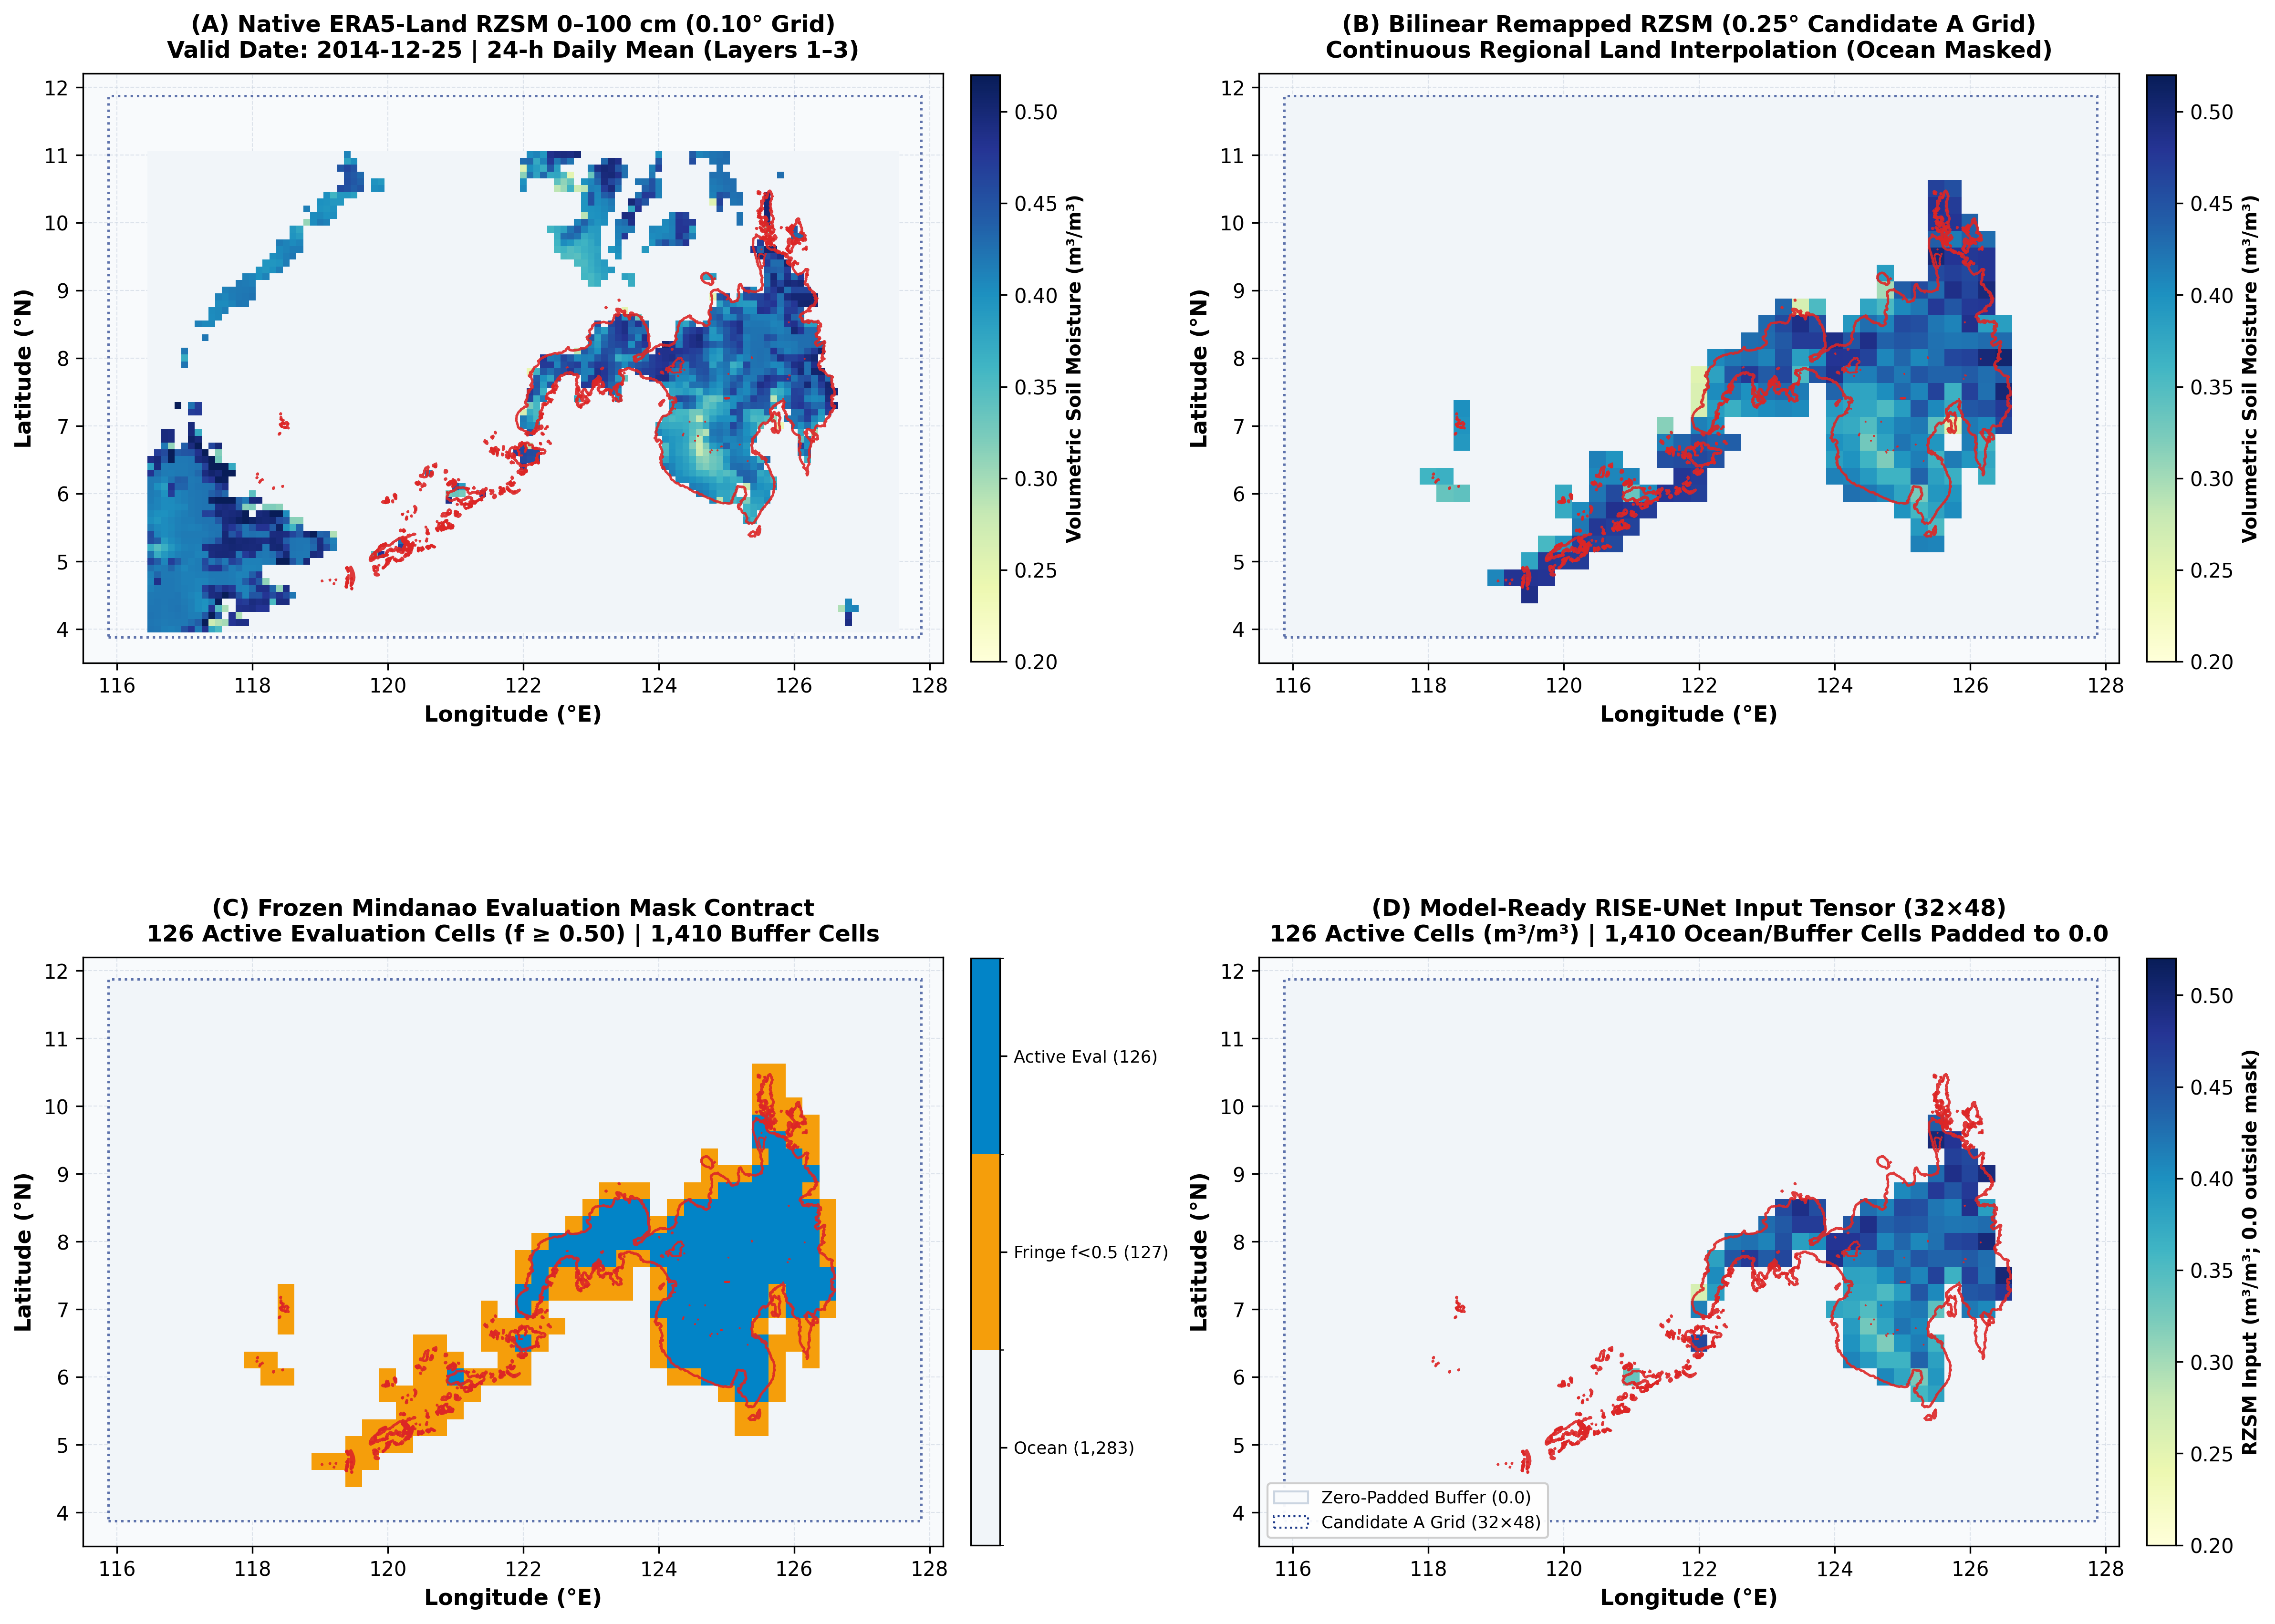

In [7]:
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import shapely.wkb

# Load Mindanao boundary geometry
conn = sqlite3.connect(GPKG_FILE)
cur = conn.cursor()
cur.execute("SELECT geom FROM mindanao_analysis_boundary LIMIT 1")
row = cur.fetchone()
conn.close()

raw_geom = row[0]
flags = raw_geom[3]
envelope_type = (flags >> 1) & 0x07
header_lens = {0: 8, 1: 40, 2: 56, 3: 56, 4: 72}
h_len = header_lens.get(envelope_type, 8)
boundary_geom = shapely.wkb.loads(raw_geom[h_len:])

def plot_boundary(ax, geom, edgecolor='#dc2626', linewidth=1.1, alpha=0.9):
    geoms = geom.geoms if geom.geom_type == 'MultiPolygon' else [geom]
    for p in geoms:
        x, y = p.exterior.xy
        ax.plot(x, y, color=edgecolor, linewidth=linewidth, alpha=alpha, zorder=6)
        for interior in p.interiors:
            ix, iy = interior.xy
            ax.plot(ix, iy, color=edgecolor, linewidth=linewidth*0.7, alpha=alpha, zorder=6)

t_idx = 13  # Dec 25, 2014 benchmark date
sample_date = str(daily_ds[time_dim].values[t_idx])[:10]

native_rzsm = rzsm_daily.isel({time_dim: t_idx}).values
native_lats = ds_2014['latitude'].values
native_lons = ds_2014['longitude'].values

lat_step_src = abs(native_lats[1] - native_lats[0]) / 2.0
lon_step_src = abs(native_lons[1] - native_lons[0]) / 2.0
extent_native = [
    native_lons.min() - lon_step_src, native_lons.max() + lon_step_src,
    native_lats.min() - lat_step_src, native_lats.max() + lat_step_src
]

lon_step_tgt = 0.25 / 2.0
lat_step_tgt = 0.25 / 2.0
extent_cand_a = [
    target_lons.min() - lon_step_tgt, target_lons.max() + lon_step_tgt,
    target_lats.min() - lat_step_tgt, target_lats.max() + lat_step_tgt
]

# Land points interpolation for Panel B
frac_ds = xr.open_dataset(FRAC_FILE)
frac_cov = frac_ds['fractional_coverage'].values

valid_src = np.isfinite(native_rzsm)
src_pts = np.column_stack([LON_src[valid_src], LAT_src[valid_src]])
src_vals = native_rzsm[valid_src]

land_cells = frac_cov > 0
land_pts = np.column_stack([LON_tgt[land_cells], LAT_tgt[land_cells]])
linear_interp = griddata(src_pts, src_vals, land_pts, method='linear')
nearest_interp = NearestNDInterpolator(src_pts, src_vals)(land_pts)
land_remapped_vals = np.where(np.isfinite(linear_interp), linear_interp, nearest_interp)

panel_b_field = np.full((32, 48), np.nan, dtype=np.float32)
panel_b_field[land_cells] = land_remapped_vals

fig, axes = plt.subplots(2, 2, figsize=(16, 12.5), dpi=300)
cmap_sm = plt.cm.YlGnBu.copy()
cmap_sm.set_bad(color='#f1f5f9')
vmin_p, vmax_p = 0.20, 0.52

xlims = (115.5, 128.2)
ylims = (3.5, 12.2)

for ax in axes.flat:
    ax.set_facecolor('#f8fafc')
    ax.set_aspect('equal')
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    ax.set_xlabel("Longitude (°E)", fontsize=11, fontweight='semibold')
    ax.set_ylabel("Latitude (°N)", fontsize=11, fontweight='semibold')
    ax.grid(color='#cbd5e1', linestyle='--', linewidth=0.5, alpha=0.6, zorder=1)
    ax.tick_params(labelsize=10)

    # Candidate A domain bounding rectangle
    cand_rect = patches.Rectangle(
        (115.875, 3.875), 127.875 - 115.875, 11.875 - 3.875,
        linewidth=1.2, edgecolor='#1e3a8a', facecolor='none',
        linestyle=':', alpha=0.7, zorder=4
    )
    ax.add_patch(cand_rect)

# --- Panel A: Native ERA5-Land ---
im0 = axes[0, 0].imshow(native_rzsm, extent=extent_native, origin='upper',
                        cmap=cmap_sm, vmin=vmin_p, vmax=vmax_p, zorder=2)
plot_boundary(axes[0, 0], boundary_geom, edgecolor='#dc2626', linewidth=1.2)
axes[0, 0].set_title(f"(A) Native ERA5-Land RZSM 0–100 cm (0.10° Grid)\nValid Date: {sample_date} | 24-h Daily Mean (Layers 1–3)",
                     fontsize=11.5, fontweight='bold', pad=8)
cb0 = plt.colorbar(im0, ax=axes[0, 0], fraction=0.032, pad=0.03)
cb0.set_label("Volumetric Soil Moisture (m³/m³)", fontsize=9.5, fontweight='semibold')

# --- Panel B: Bilinear Remapped RZSM ---
im1 = axes[0, 1].imshow(panel_b_field, extent=extent_cand_a, origin='upper',
                        cmap=cmap_sm, vmin=vmin_p, vmax=vmax_p, zorder=2)
plot_boundary(axes[0, 1], boundary_geom, edgecolor='#dc2626', linewidth=1.2)
axes[0, 1].set_title(f"(B) Bilinear Remapped RZSM (0.25° Candidate A Grid)\nContinuous Regional Land Interpolation (Ocean Masked)",
                     fontsize=11.5, fontweight='bold', pad=8)
cb1 = plt.colorbar(im1, ax=axes[0, 1], fraction=0.032, pad=0.03)
cb1.set_label("Volumetric Soil Moisture (m³/m³)", fontsize=9.5, fontweight='semibold')

# --- Panel C: Frozen Binary Evaluation Mask ---
mask_display = np.full((32, 48), np.nan, dtype=np.float32)
mask_display[frac_cov == 0] = 0
mask_display[(frac_cov > 0) & (eval_mask == 0)] = 1
mask_display[eval_mask == 1] = 2

cmap_mask = mcolors.ListedColormap(['#f1f5f9', '#f59e0b', '#0284c7'])
bounds_mask = [-0.5, 0.5, 1.5, 2.5]
norm_mask = mcolors.BoundaryNorm(bounds_mask, cmap_mask.N)

im2 = axes[1, 0].imshow(mask_display, extent=extent_cand_a, origin='upper',
                        cmap=cmap_mask, norm=norm_mask, zorder=2)
plot_boundary(axes[1, 0], boundary_geom, edgecolor='#dc2626', linewidth=1.2)
axes[1, 0].set_title("(C) Frozen Mindanao Evaluation Mask Contract\n126 Active Evaluation Cells (f ≥ 0.50) | 1,410 Buffer Cells",
                     fontsize=11.5, fontweight='bold', pad=8)
cb2 = plt.colorbar(im2, ax=axes[1, 0], fraction=0.032, pad=0.03, ticks=[0, 1, 2])
cb2.set_ticklabels(['Ocean (1,283)', 'Fringe f<0.5 (127)', 'Active Eval (126)'])
cb2.ax.tick_params(labelsize=8.5)

# --- Panel D: Model-Ready Input Tensor ---
masked_tensor_display = np.full((32, 48), np.nan, dtype=np.float32)
masked_tensor_display[eval_mask == 1] = output_tensor[t_idx, eval_mask == 1]

im3 = axes[1, 1].imshow(masked_tensor_display, extent=extent_cand_a, origin='upper',
                        cmap=cmap_sm, vmin=vmin_p, vmax=vmax_p, zorder=2)
plot_boundary(axes[1, 1], boundary_geom, edgecolor='#dc2626', linewidth=1.2)
axes[1, 1].set_title(f"(D) Model-Ready RISE-UNet Input Tensor (32×48)\n126 Active Cells (m³/m³) | 1,410 Ocean/Buffer Cells Padded to 0.0",
                     fontsize=11.5, fontweight='bold', pad=8)
cb3 = plt.colorbar(im3, ax=axes[1, 1], fraction=0.032, pad=0.03)
cb3.set_label("RZSM Input (m³/m³; 0.0 outside mask)", fontsize=9.5, fontweight='semibold')

patch_zero = patches.Patch(facecolor='#f8fafc', edgecolor='#cbd5e1', label='Zero-Padded Buffer (0.0)')
patch_bbox = patches.Patch(facecolor='none', edgecolor='#1e3a8a', linestyle=':', label='Candidate A Grid (32×48)')
axes[1, 1].legend(handles=[patch_zero, patch_bbox], loc='lower left', fontsize=8.5, framealpha=0.95)

plt.tight_layout()
fig_out = REPO_DIR / "processed" / "grid" / "figures" / "mindanao_rzsm_pilot_preprocessing_composite.png"
fig_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_out, bbox_inches='tight', dpi=300)
print(f"Publication composite map saved to: {fig_out}")
plt.show()


### Step 6: Package CF-1.8 NetCDF & Synchronize to GCS Export
Export the preprocessed depth-weighted RZSM tensors with standardized CF-1.8 metadata, and upload to `gs://rise-unet-rzsm/processed/rzsm/pilot/`.

In [8]:
dates_out = daily_ds[time_dim].values

pilot_ds = xr.Dataset(
    data_vars={
        'rzsm_0_100_masked': (('time', 'lat', 'lon'), output_tensor.astype(np.float32)),
        'evaluation_mask': (('lat', 'lon'), eval_mask.astype(np.int8))
    },
    coords={
        'time': dates_out,
        'lat': target_lats,
        'lon': target_lons
    },
    attrs={
        'title': 'ERA5-Land Pilot Depth-Weighted RZSM (0-100 cm) over Mindanao 0.25deg Grid',
        'author': 'Mindanao RZSM Subseasonal Drought Forecasting Project',
        'methodology': 'Lesinger & Tian (2025) Track B Adaptation',
        'formula': 'RZSM_0_100 = 0.07*swvl1 + 0.21*swvl2 + 0.72*swvl3',
        'spatial_grid': 'Candidate_A_Mindanao_32x48',
        'active_evaluation_cells': 126,
        'conventions': 'CF-1.8'
    }
)

out_nc = REPO_DIR / "processed" / "rzsm" / "pilot" / "era5_land_rzsm_pilot_2014_2015.nc"
out_nc.parent.mkdir(parents=True, exist_ok=True)
pilot_ds.to_netcdf(out_nc)
print(f"Exported preprocessed NetCDF: {out_nc} ({out_nc.stat().st_size / (1024*1024):.2f} MB)")

# Upload to GCS if authenticated
try:
    res = subprocess.run(["gcloud", "storage", "cp", str(out_nc), "gs://rise-unet-rzsm/processed/rzsm/pilot/"], capture_output=True, text=True)
    if res.returncode == 0:
        print("Successfully uploaded pilot processed NetCDF to GCS gs://rise-unet-rzsm/processed/rzsm/pilot/")
    else:
        print(f"Note on GCS upload: {res.stderr.strip()}")
except Exception as e:
    print(f"Note on GCS upload execution: {e}")

print("\n" + "=" * 65)
print("SUB-PHASE 21B (STEPS 21B.3 & 21B.4) COMPLETE AND CERTIFIED!")
print("=" * 65)

Exported preprocessed NetCDF: /content/rise-unet-rzsm/processed/rzsm/pilot/era5_land_rzsm_pilot_2014_2015.nc (0.13 MB)
Successfully uploaded pilot processed NetCDF to GCS gs://rise-unet-rzsm/processed/rzsm/pilot/

SUB-PHASE 21B (STEPS 21B.3 & 21B.4) COMPLETE AND CERTIFIED!
